# PubHealth Dataset — First Analysis
ASHO-UAB Fake News Prediction Project

In [14]:
# Install dependencies
!pip install datasets pandas matplotlib seaborn -q
!pip install transformers datasets evaluate seqeval pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 475.7 kB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.1 MB/s eta 0:00:00a 0:00:01
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=91ef0e6c5eb84537bf387ba96074a8a1d9c5d5ed109db13d254bd38e4ea79b07
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

import pandas as pd

train_df = pd.read_csv('/kaggle/input/datasets/albeerrtt/pubhealth/dev.tsv', sep='\t')
val_df   = pd.read_csv('/kaggle/input/datasets/albeerrtt/pubhealth/dev.tsv',   sep='\t')
test_df  = pd.read_csv('/kaggle/input/datasets/albeerrtt/pubhealth/test.tsv',  sep='\t')

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
train_df.head(3)

Train: 1221 | Val: 1221 | Test: 1235


,claim_id,claim,date_published,explanation,fact_checkers,main_text,sources,label,subjects
0,34656,A baby died at an unnamed medical facility be...,"November 10, 2015",Fellow Twitter users suggested @FierceFemtivis...,Kim LaCapria,"On 8 November 2015, former Twitter user @Fierc...",http://webcache.googleusercontent.com/search?q...,unproven,"Politics, fiercefemtivist, racism"
1,3632,Bat from Shawnee County tests positive for rab...,NaN,A bat found in northeastern Kansas has tested ...,,Topeka television station KSNT reports that th...,https://www.ksnt.com/news/bat-tests-positive-f...,true,"Rabies, Health, General News, Kansas, Bats, To..."
2,29558,Germany has banned pork from school canteens b...,"March 7, 2016",What's true: Some politicians complained that ...,Kim LaCapria,"On 7 March 2016, British tabloid Express repor...",http://bnp.org.uk/news/regional/bnp-victory-br...,false,Politics


In [16]:
# Basic info
print(train_df.dtypes)
print("\nMissing values (train):")
print(train_df.isnull().sum())

claim_id          object
claim             object
date_published    object
explanation       object
fact_checkers     object
main_text         object
sources           object
label             object
subjects          object
dtype: object

Missing values (train):
claim_id            0
claim               2
date_published    245
explanation         2
fact_checkers       4
main_text           4
sources             5
label               6
subjects            7
dtype: int64


## 1. Label Distribution

/tmp/ipykernel_55/3111586564.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='Set2')
/tmp/ipykernel_55/3111586564.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='Set2')
/tmp/ipykernel_55/3111586564.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='Set2')


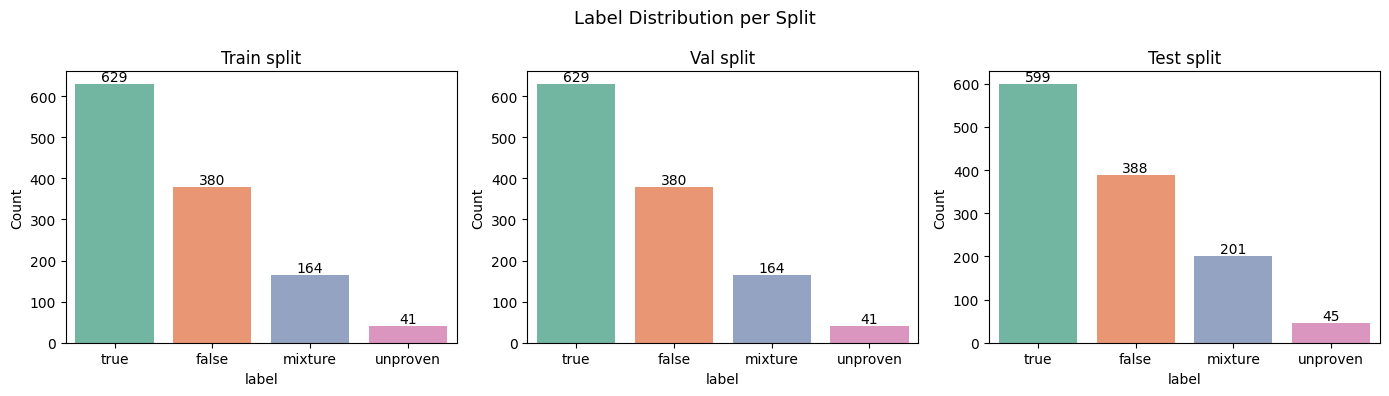

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    counts = df['label'].value_counts()
    # plot only first 4 labels for better visualization
    counts = counts.head(4)
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='Set2')
    ax.set_title(f'{name} split')
    ax.set_ylabel('Count')
    for p in ax.patches:
        ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.suptitle('Label Distribution per Split', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Text Length Analysis

In [18]:
for col in ['claim', 'main_text', 'explanation']:
    train_df[f'{col}_len'] = train_df[col].fillna('').apply(lambda x: len(x.split()))

train_df[['claim_len', 'main_text_len', 'explanation_len']].describe().round(1)

,claim_len,main_text_len,explanation_len
count,1221.0,1221.0,1221.0
mean,13.3,704.3,77.0
std,7.1,481.1,96.0
min,0.0,0.0,0.0
25%,8.0,387.0,26.0
50%,11.0,611.0,38.0
75%,17.0,904.0,84.0
max,67.0,4665.0,1255.0


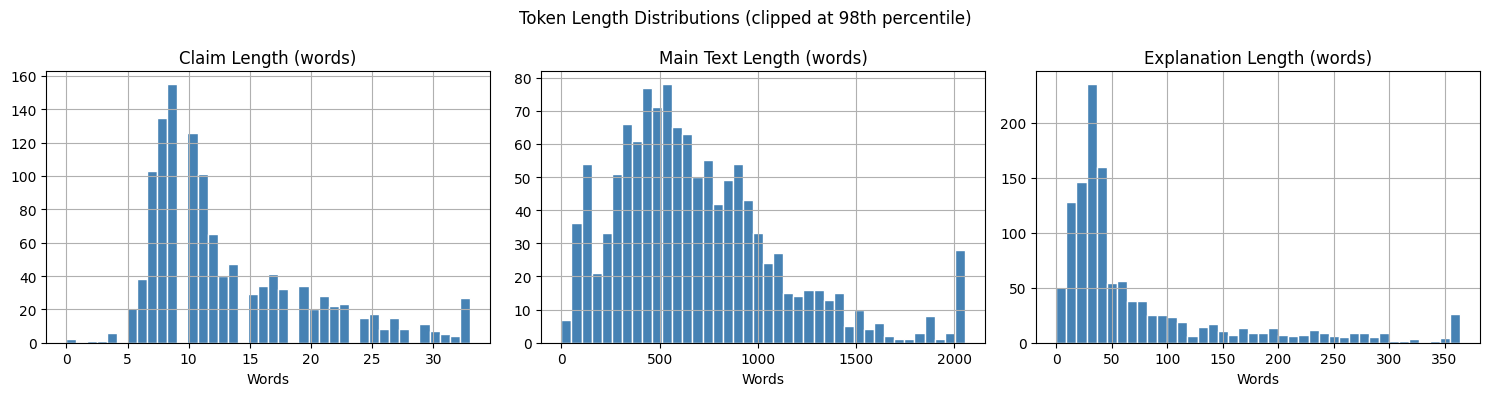

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['claim_len', 'main_text_len', 'explanation_len']):
    train_df[col].clip(upper=train_df[col].quantile(0.98)).hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_len', '').replace('_', ' ').title() + ' Length (words)')
    ax.set_xlabel('Words')
plt.suptitle('Token Length Distributions (clipped at 98th percentile)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Length vs Label

/tmp/ipykernel_55/1791203149.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y=col, ax=ax, palette='Set2',
/tmp/ipykernel_55/1791203149.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y=col, ax=ax, palette='Set2',


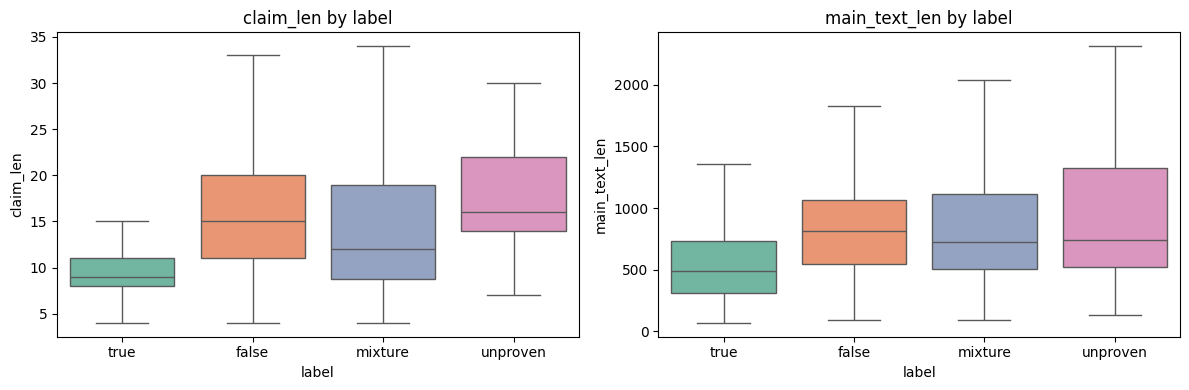

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['claim_len', 'main_text_len']):
    sns.boxplot(data=train_df, x='label', y=col, ax=ax, palette='Set2',
                order=['true','false','mixture','unproven'],
                showfliers=False)
    ax.set_title(f'{col} by label')
plt.tight_layout()
plt.show()

## 4. Missing Data Heatmap

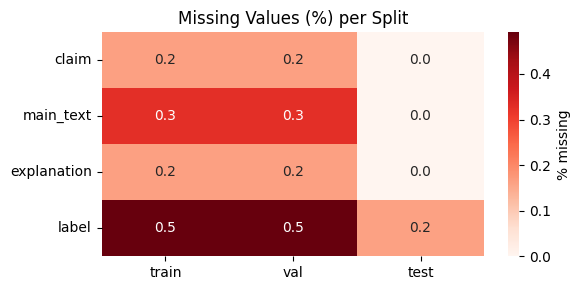

In [21]:
cols_of_interest = ['claim', 'main_text', 'explanation', 'label']
missing = pd.DataFrame({
    split: df[cols_of_interest].isnull().mean() * 100
    for split, df in [('train', train_df), ('val', val_df), ('test', test_df)]
})

plt.figure(figsize=(6, 3))
sns.heatmap(missing, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': '% missing'})
plt.title('Missing Values (%) per Split')
plt.tight_layout()
plt.show()

## 5. Sample Claims per Label

In [22]:
for label in ['true', 'false', 'mixture', 'unproven']:
    sample = train_df[train_df['label'] == label]['claim'].dropna().sample(1, random_state=42).values[0]
    print(f"[{label.upper()}] {sample[:200]}\n")

[TRUE] California to require abortion medication at public colleges.

[FALSE] Sleep apnea patient finds rest with implant device: "It saved my life

[MIXTURE] New Stomach Stapling Procedure: No Surgery, Less Recovery Time

[UNPROVEN] A cryptic blog called "Two Droplets" told the story of the catastrophic effect of two droplets of drain cleaner on a family's life.



# Baseline

In [30]:
# baseline_train.py
import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from datasets import Dataset, DatasetDict
import evaluate
import torch

# Drop rows with missing claim, main_text, or label
cols_needed = ['claim', 'main_text', 'label']
for df_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    before = len(df)
    df.dropna(subset=cols_needed, inplace=True)
    print(f"{df_name}: dropped {before - len(df)} rows with missing values")

# Concatenate claim and main_text with a separator
def combine_text(row):
    claim = str(row['claim']) if pd.notna(row['claim']) else ''
    main  = str(row['main_text']) if pd.notna(row['main_text']) else ''
    return f"{claim} [SEP] {main}"

train_df['text'] = train_df.apply(combine_text, axis=1)
val_df['text']   = val_df.apply(combine_text, axis=1)
test_df['text']  = test_df.apply(combine_text, axis=1)

# Map labels to integers
label_list = ['true', 'false', 'mixture', 'unproven']
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

train_df['labels'] = train_df['label'].map(label2id)
val_df['labels']   = val_df['label'].map(label2id)
test_df['labels']  = test_df['label'].map(label2id)

# Drop rows where label mapping produced NaN (any label not in our list)
for df_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    before_len = len(df)
    df.dropna(subset=['labels'], inplace=True)
    print(f"{df_name}: dropped {before_len - len(df)} rows due to NaN labels")

# Now convert to plain integers
train_df['labels'] = train_df['labels'].astype(int)
val_df['labels']   = val_df['labels'].astype(int)
test_df['labels']  = test_df['labels'].astype(int)

# Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['text', 'labels']])
val_dataset   = Dataset.from_pandas(val_df[['text', 'labels']])
test_dataset  = Dataset.from_pandas(test_df[['text', 'labels']])

dataset = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset,
})

# -------------------------------
# 2. Tokenization
# -------------------------------
model_name = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=512,
        padding=False,  # we'll pad with DataCollator
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# -------------------------------
# 3. Prepare the Model
# -------------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)

# Calculate class weights for imbalanced data
train_labels = train_df['labels'].values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

# -------------------------------
# 4. Define Metrics
# -------------------------------
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1_macro = f1_metric.compute(predictions=predictions, references=labels, average='macro')
    return {"accuracy": acc['accuracy'], "macro_f1": f1_macro['f1']}

# -------------------------------
# 5. Training Arguments
# -------------------------------
training_args = TrainingArguments(
    output_dir='./pubmedbert_pubhealth',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    logging_dir='./logs',
    logging_steps=100,
    fp16=True,  # if GPU supports it
    report_to='none',
)

# -------------------------------
# 6. Data Collator
# -------------------------------
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# -------------------------------
# 7. Trainer (with custom loss for class weights)
# -------------------------------
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# -------------------------------
# 8. Train and Evaluate
# -------------------------------
trainer.train()

# Evaluate on test set
test_results = trainer.evaluate(tokenized_datasets['test'])
print("Test results:", test_results)

# Save the best model
trainer.save_model("./pubmedbert_pubhealth_best")
tokenizer.save_pretrained("./pubmedbert_pubhealth_best")

train: dropped 0 rows with missing values
val: dropped 0 rows with missing values
test: dropped 0 rows with missing values
train: dropped 0 rows due to NaN labels
val: dropped 0 rows due to NaN labels
test: dropped 0 rows due to NaN labels


Map:   0%|          | 0/1214 [00:00<?, ? examples/s]

Map:   0%|          | 0/1214 [00:00<?, ? examples/s]

Map:   0%|          | 0/1233 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Test results: {'eval_loss': 1.2367429733276367, 'eval_accuracy': 0.6545012165450121, 'eval_macro_f1': 0.4910443236685668, 'eval_runtime': 731.5724, 'eval_samples_per_second': 1.685, 'eval_steps_per_second': 0.107, 'epoch': 5.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./pubmedbert_pubhealth_best/tokenizer_config.json',
 './pubmedbert_pubhealth_best/tokenizer.json')

In [31]:
!zip -r pubmedbert_pubhealth_best.zip ./pubmedbert_pubhealth_best
from IPython.display import FileLink
FileLink("pubmedbert_pubhealth_best.zip")

  adding: pubmedbert_pubhealth_best/ (stored 0%)
  adding: pubmedbert_pubhealth_best/model.safetensors (deflated 7%)
  adding: pubmedbert_pubhealth_best/tokenizer.json (deflated 71%)
  adding: pubmedbert_pubhealth_best/config.json (deflated 53%)
  adding: pubmedbert_pubhealth_best/tokenizer_config.json (deflated 41%)
  adding: pubmedbert_pubhealth_best/training_args.bin (deflated 53%)


/kaggle/working/pubmedbert_pubhealth_best.zip